# Lower Mortgage — Consumer Contact Strategy EDA

Exploratory data analysis of DTC lead and call activity data (Nov 2025 – Jan 2026).  
**Scope:** Pool A outbound dials only, excluding records where activity timestamp < lead created timestamp.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

LOWER_BLUE = '#1a3a5c'
LOWER_TEAL = '#2ca58d'
LOWER_ORANGE = '#e07a3a'
LOWER_RED = '#c44e52'
LOWER_GRAY = '#8c8c8c'
PALETTE = [LOWER_BLUE, LOWER_TEAL, LOWER_ORANGE, LOWER_RED, '#6a4c93', '#f4a261', LOWER_GRAY]

---
## Phase 0 — Data Profile Summary

| Metric | Value |
|---|---|
| **dim_leads rows** | 35,169 (excl. totals row) |
| **fct_dials rows** | 382,454 |
| **Date range (lead created)** | 2025-11-01 to 2026-01-31 |
| **Activity date range** | 2025-08-18 to 2026-02-13 |
| **Leads never called** | 4,154 (11.8%) |
| **Bad timestamps (activity < created)** | 1,166 (0.3%) — suppressed |
| **Pool A dials** | 291,328 (76.2%) |
| **Non-Pool A dials** | 91,126 (23.8%) |
| **Outbound / Inbound** | 363,743 / 18,711 |

---
## Phase 1 — Lead Universe & Funnel Overview

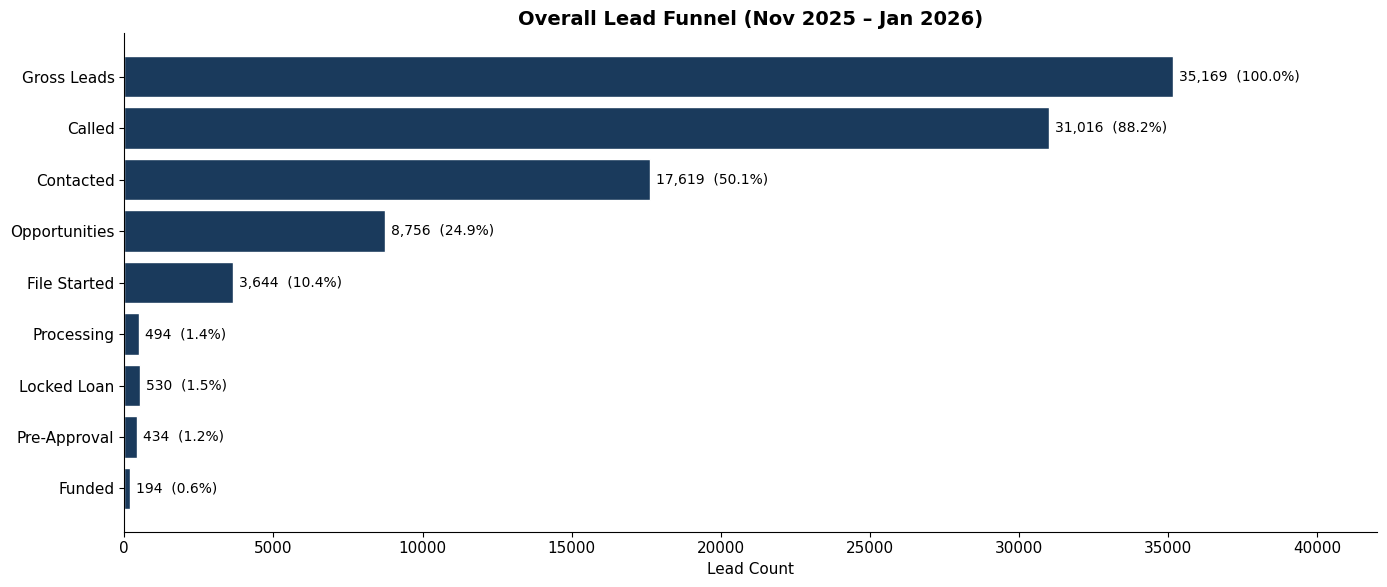


Stage-to-Stage Conversion Rates:
  Gross Leads → Called: 88.2%
  Called → Contacted: 56.8%
  Contacted → Opportunities: 49.7%
  Opportunities → File Started: 41.6%
  File Started → Processing: 13.6%
  Processing → Locked Loan: 107.3%
  Locked Loan → Pre-Approval: 81.9%
  Pre-Approval → Funded: 44.7%


In [30]:
funnel_stages = ['Gross Leads', 'Called', 'Contacted', 'Opportunities',
                 'File Started', 'Processing', 'Locked Loan', 'Pre-Approval', 'Funded']
funnel_values = [35169, 31016, 17619, 8756, 3644, 494, 530, 434, 194]

funnel_df = pd.DataFrame({'Stage': funnel_stages, 'Count': funnel_values})
funnel_df['Rate_vs_Gross'] = (funnel_df['Count'] / funnel_df['Count'].iloc[0] * 100).round(1)
funnel_df['Stage_Rate'] = [100.0] + [
    round(funnel_df['Count'].iloc[i] / funnel_df['Count'].iloc[i-1] * 100, 1)
    for i in range(1, len(funnel_df))
]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(funnel_df['Stage'][::-1], funnel_df['Count'][::-1], color=LOWER_BLUE, edgecolor='white')
for bar, val, rate in zip(bars, funnel_df['Count'][::-1], funnel_df['Rate_vs_Gross'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({rate}%)', va='center', fontsize=10)
ax.set_title('Overall Lead Funnel (Nov 2025 – Jan 2026)')
ax.set_xlabel('Lead Count')
ax.set_xlim(0, 42000)
plt.tight_layout()
plt.show()

print('\nStage-to-Stage Conversion Rates:')
for i in range(1, len(funnel_df)):
    prev = funnel_df['Stage'].iloc[i-1]
    curr = funnel_df['Stage'].iloc[i]
    rate = funnel_df['Stage_Rate'].iloc[i]
    print(f'  {prev} → {curr}: {rate}%')

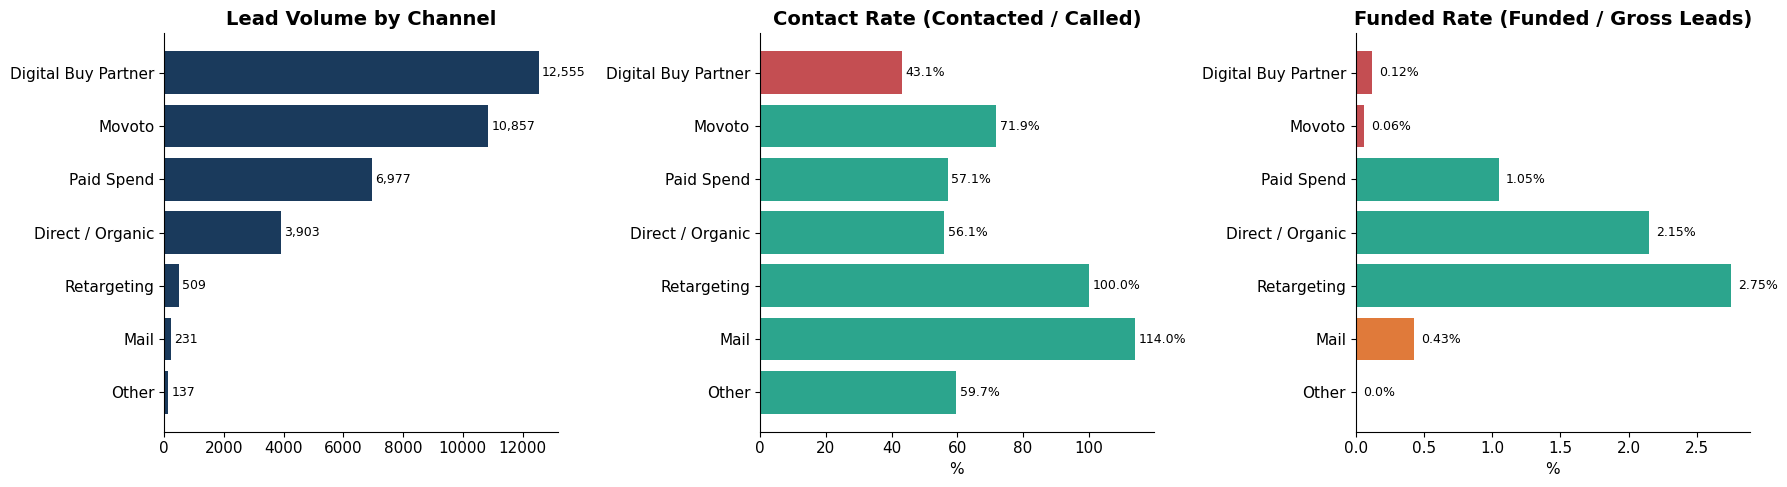


Channel Funnel Summary:
            Channel  Gross  Contact Rate  Opp Rate  Funded Rate (vs Gross)
Digital Buy Partner  12555          43.1      46.1                    0.12
             Movoto  10857          71.9      36.8                    0.06
         Paid Spend   6977          57.1      77.5                    1.05
   Direct / Organic   3903          56.1      77.7                    2.15
        Retargeting    509         100.0       9.2                    2.75
               Mail    231         114.0       6.1                    0.43
              Other    137          59.7      73.0                    0.00


In [31]:
channel_data = {
    'Channel': ['Digital Buy Partner', 'Movoto', 'Paid Spend', 'Direct / Organic', 'Retargeting', 'Mail', 'Other'],
    'Gross': [12555, 10857, 6977, 3903, 509, 231, 137],
    'Called': [12509, 9236, 5138, 3300, 509, 200, 124],
    'Contacted': [5386, 6638, 2934, 1850, 509, 228, 74],
    'Opportunities': [2483, 2445, 2275, 1438, 47, 14, 54],
    'File Started': [762, 606, 1135, 914, 136, 57, 34],
    'Funded': [15, 7, 73, 84, 14, 1, 0],
}
ch_df = pd.DataFrame(channel_data)
ch_df['Contact Rate'] = (ch_df['Contacted'] / ch_df['Called'] * 100).round(1)
ch_df['Opp Rate'] = (ch_df['Opportunities'] / ch_df['Contacted'] * 100).round(1)
ch_df['Funded Rate (vs Gross)'] = (ch_df['Funded'] / ch_df['Gross'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(ch_df['Channel'][::-1], ch_df['Gross'][::-1], color=LOWER_BLUE)
axes[0].set_title('Lead Volume by Channel')
for bar, val in zip(axes[0].patches, ch_df['Gross'][::-1]):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

colors_cr = [LOWER_TEAL if v >= 55 else LOWER_ORANGE if v >= 45 else LOWER_RED for v in ch_df['Contact Rate'][::-1]]
axes[1].barh(ch_df['Channel'][::-1], ch_df['Contact Rate'][::-1], color=colors_cr)
axes[1].set_title('Contact Rate (Contacted / Called)')
axes[1].set_xlabel('%')
for bar, val in zip(axes[1].patches, ch_df['Contact Rate'][::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)

colors_fr = [LOWER_TEAL if v >= 1 else LOWER_ORANGE if v >= 0.3 else LOWER_RED for v in ch_df['Funded Rate (vs Gross)'][::-1]]
axes[2].barh(ch_df['Channel'][::-1], ch_df['Funded Rate (vs Gross)'][::-1], color=colors_fr)
axes[2].set_title('Funded Rate (Funded / Gross Leads)')
axes[2].set_xlabel('%')
for bar, val in zip(axes[2].patches, ch_df['Funded Rate (vs Gross)'][::-1]):
    axes[2].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nChannel Funnel Summary:')
print(ch_df[['Channel', 'Gross', 'Contact Rate', 'Opp Rate', 'Funded Rate (vs Gross)']].to_string(index=False))

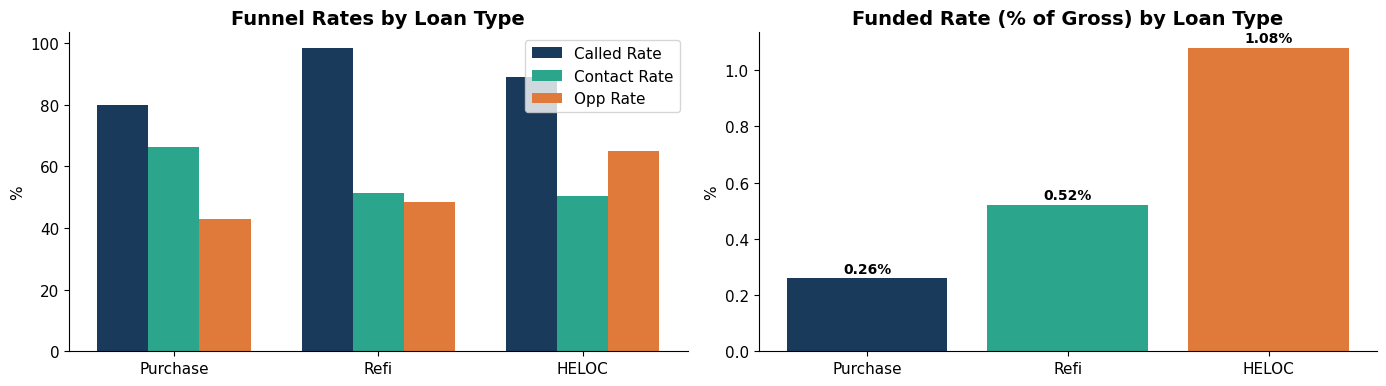


Loan Type Funnel:
Loan Type  Gross  Called  Contacted  Opportunities  File Started  Funded  Called Rate  Contact Rate  Opp Rate  Funded per Gross
 Purchase  14824   11830       7842           3363          1166      38         79.8          66.3      42.9              0.26
     Refi  11483   11311       5806           2807          1298      60         98.5          51.3      48.3              0.52
    HELOC   8862    7875       3971           2586          1180      96         88.9          50.4      65.1              1.08


In [32]:
loan_data = {
    'Loan Type': ['Purchase', 'Refi', 'HELOC'],
    'Gross': [14824, 11483, 8862],
    'Called': [11830, 11311, 7875],
    'Contacted': [7842, 5806, 3971],
    'Opportunities': [3363, 2807, 2586],
    'File Started': [1166, 1298, 1180],
    'Funded': [38, 60, 96],
}
loan_df = pd.DataFrame(loan_data)
loan_df['Called Rate'] = (loan_df['Called'] / loan_df['Gross'] * 100).round(1)
loan_df['Contact Rate'] = (loan_df['Contacted'] / loan_df['Called'] * 100).round(1)
loan_df['Opp Rate'] = (loan_df['Opportunities'] / loan_df['Contacted'] * 100).round(1)
loan_df['Funded per Gross'] = (loan_df['Funded'] / loan_df['Gross'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(loan_df))
w = 0.25
axes[0].bar(x - w, loan_df['Called Rate'], w, label='Called Rate', color=LOWER_BLUE)
axes[0].bar(x, loan_df['Contact Rate'], w, label='Contact Rate', color=LOWER_TEAL)
axes[0].bar(x + w, loan_df['Opp Rate'], w, label='Opp Rate', color=LOWER_ORANGE)
axes[0].set_xticks(x)
axes[0].set_xticklabels(loan_df['Loan Type'])
axes[0].set_ylabel('%')
axes[0].set_title('Funnel Rates by Loan Type')
axes[0].legend()

axes[1].bar(loan_df['Loan Type'], loan_df['Funded per Gross'], color=[LOWER_BLUE, LOWER_TEAL, LOWER_ORANGE])
axes[1].set_ylabel('%')
axes[1].set_title('Funded Rate (% of Gross) by Loan Type')
for i, val in enumerate(loan_df['Funded per Gross']):
    axes[1].text(i, val + 0.02, f'{val}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nLoan Type Funnel:')
print(loan_df.to_string(index=False))

---
## Phase 2 — Cadence Compliance: Are We Making 3 Calls/Day for 5 Days?

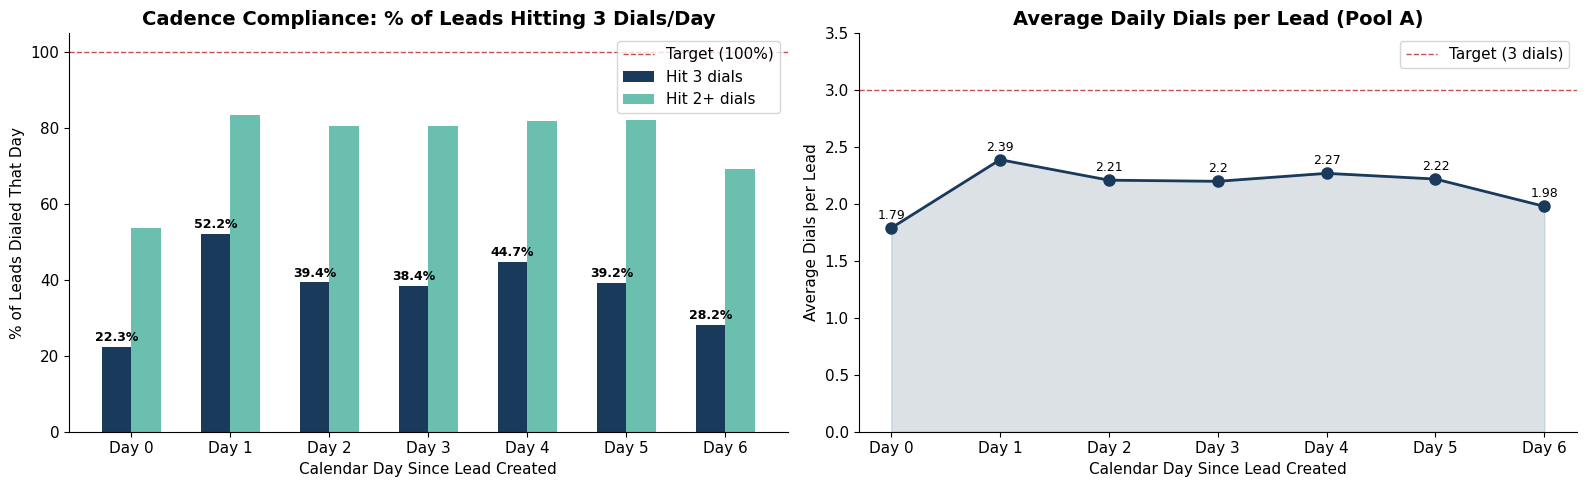

Key Finding: The 3-call/day target is NEVER met for a majority of leads.
  Best day is Day 1 at 52.2% compliance.
  Day 0 (same-day as creation) only hits 22.3% — likely due to leads arriving mid/late day.
  Average dials peak at 2.39 on Day 1, well below the 3.0 target.


In [33]:
cadence_data = {
    'Day Offset': [0, 1, 2, 3, 4, 5, 6],
    'Leads with Dials': [16067, 16091, 11704, 9465, 8875, 8986, 9457],
    'Avg Dials': [1.79, 2.39, 2.21, 2.20, 2.27, 2.22, 1.98],
    'Pct Hitting 3': [22.3, 52.2, 39.4, 38.4, 44.7, 39.2, 28.2],
    'Pct Hitting 2+': [53.8, 83.5, 80.5, 80.5, 81.8, 82.1, 69.2],
}
cad_df = pd.DataFrame(cadence_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
x = cad_df['Day Offset']
ax.bar(x - 0.15, cad_df['Pct Hitting 3'], 0.3, label='Hit 3 dials', color=LOWER_BLUE)
ax.bar(x + 0.15, cad_df['Pct Hitting 2+'], 0.3, label='Hit 2+ dials', color=LOWER_TEAL, alpha=0.7)
ax.axhline(y=100, color=LOWER_RED, linestyle='--', linewidth=1, label='Target (100%)')
ax.set_xlabel('Calendar Day Since Lead Created')
ax.set_ylabel('% of Leads Dialed That Day')
ax.set_title('Cadence Compliance: % of Leads Hitting 3 Dials/Day')
ax.set_xticks(range(7))
ax.set_xticklabels([f'Day {i}' for i in range(7)])
ax.legend()
for i, val in enumerate(cad_df['Pct Hitting 3']):
    ax.text(i - 0.15, val + 1.5, f'{val}%', ha='center', fontsize=9, fontweight='bold')

ax2 = axes[1]
ax2.plot(x, cad_df['Avg Dials'], marker='o', color=LOWER_BLUE, linewidth=2, markersize=8)
ax2.axhline(y=3, color=LOWER_RED, linestyle='--', linewidth=1, label='Target (3 dials)')
ax2.fill_between(x, cad_df['Avg Dials'], alpha=0.15, color=LOWER_BLUE)
ax2.set_xlabel('Calendar Day Since Lead Created')
ax2.set_ylabel('Average Dials per Lead')
ax2.set_title('Average Daily Dials per Lead (Pool A)')
ax2.set_xticks(range(7))
ax2.set_xticklabels([f'Day {i}' for i in range(7)])
ax2.set_ylim(0, 3.5)
ax2.legend()
for i, val in enumerate(cad_df['Avg Dials']):
    ax2.text(i, val + 0.08, f'{val}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Key Finding: The 3-call/day target is NEVER met for a majority of leads.')
print(f'  Best day is Day 1 at {cad_df["Pct Hitting 3"].max()}% compliance.')
print(f'  Day 0 (same-day as creation) only hits 22.3% — likely due to leads arriving mid/late day.')
print(f'  Average dials peak at {cad_df["Avg Dials"].max()} on Day 1, well below the 3.0 target.')

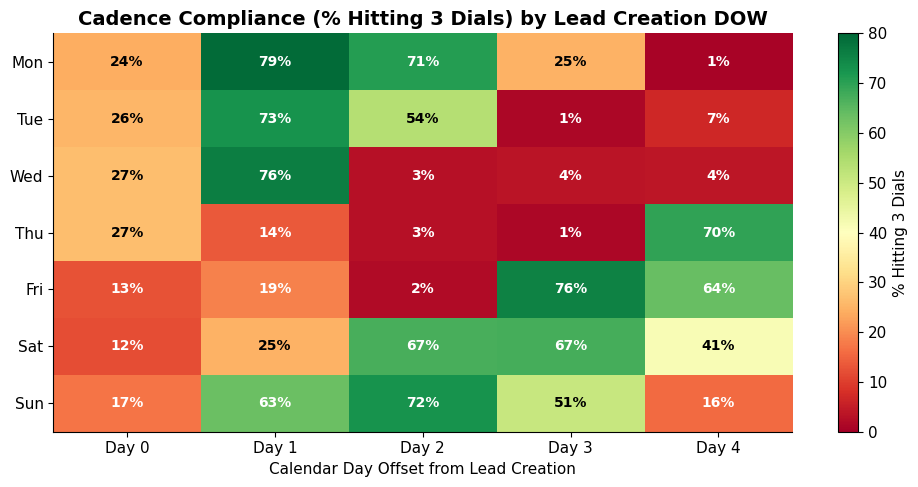

Key Finding: Weekend effect is massive.
  Leads created Wed–Thu see compliance crater on Days 2-3 (weekend).
  Leads created Fri see low Day 0 (12.8%) and Day 1 (18.6%) — Sat/Sun staffing is thin.
  Best compliance happens on weekdays following weekday lead creation (Mon→Tue, Tue→Wed, etc.).


In [34]:
dow_cadence = {
    'DOW': ['Mon','Mon','Mon','Mon','Mon','Tue','Tue','Tue','Tue','Tue',
            'Wed','Wed','Wed','Wed','Wed','Thu','Thu','Thu','Thu','Thu',
            'Fri','Fri','Fri','Fri','Fri','Sat','Sat','Sat','Sat','Sat',
            'Sun','Sun','Sun','Sun','Sun'],
    'Day Offset': [0,1,2,3,4]*7,
    'Pct Hitting 3': [
        24.2, 79.1, 70.7, 24.9, 0.9,
        25.5, 72.7, 53.5, 1.3, 6.7,
        26.8, 76.1, 3.1, 3.5, 3.9,
        26.6, 13.6, 2.9, 1.3, 69.5,
        12.8, 18.6, 2.0, 75.5, 63.5,
        12.1, 24.8, 67.1, 67.4, 41.3,
        16.9, 63.4, 72.5, 50.7, 15.9,
    ],
}
dow_df = pd.DataFrame(dow_cadence)
pivot = dow_df.pivot(index='DOW', columns='Day Offset', values='Pct Hitting 3')
dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot = pivot.reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=80)
ax.set_xticks(range(5))
ax.set_xticklabels([f'Day {i}' for i in range(5)])
ax.set_yticks(range(7))
ax.set_yticklabels(dow_order)
ax.set_title('Cadence Compliance (% Hitting 3 Dials) by Lead Creation DOW')
ax.set_xlabel('Calendar Day Offset from Lead Creation')

for i in range(7):
    for j in range(5):
        val = pivot.values[i, j]
        color = 'white' if val < 20 or val > 60 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='% Hitting 3 Dials')
plt.tight_layout()
plt.show()

print('Key Finding: Weekend effect is massive.')
print('  Leads created Wed–Thu see compliance crater on Days 2-3 (weekend).')
print('  Leads created Fri see low Day 0 (12.8%) and Day 1 (18.6%) — Sat/Sun staffing is thin.')
print('  Best compliance happens on weekdays following weekday lead creation (Mon→Tue, Tue→Wed, etc.).')

---
## Phase 3 — Funnel Decay by Attempt Number & Day

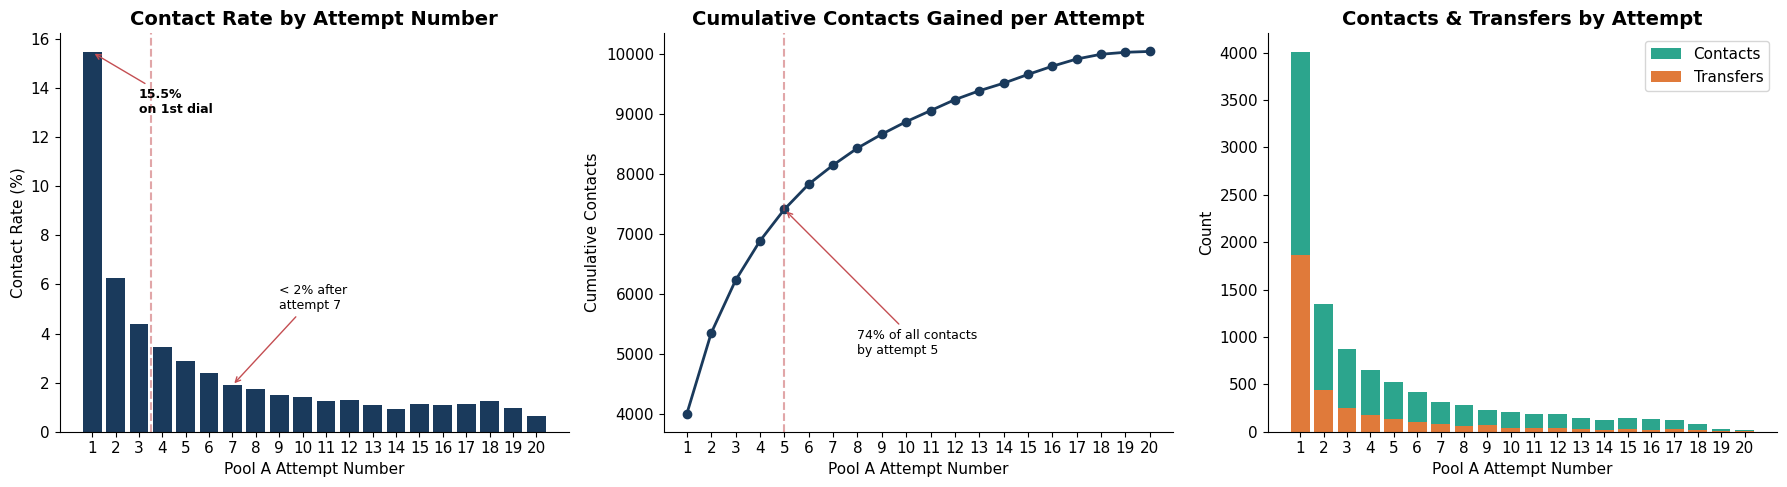


First attempt contact rate: 15.5% — nearly 2.5x the second attempt (6.3%)
Attempts 1-5 capture 74% of all Pool A contacts
After attempt 7, contact rate drops below 2% — deep diminishing returns


In [35]:
attempt_data = {
    'Attempt': list(range(1, 21)),
    'Dials': [25891,21479,19971,19008,18278,17484,16764,16238,15322,14822,
              14473,14078,13774,13396,13064,12575,10544,6319,3460,2146],
    'Contacts': [4004,1343,878,655,525,420,317,283,232,208,
                 184,183,148,126,146,137,120,79,33,14],
    'Contact Rate': [15.46,6.25,4.40,3.45,2.87,2.40,1.89,1.74,1.51,1.40,
                     1.27,1.30,1.07,0.94,1.12,1.09,1.14,1.25,0.95,0.65],
    'Transfers': [1866,438,255,179,137,101,82,63,68,42,43,41,32,23,27,19,24,13,8,5],
}
att_df = pd.DataFrame(attempt_data)
att_df['Cumul Contacts'] = att_df['Contacts'].cumsum()
att_df['Cumul Transfers'] = att_df['Transfers'].cumsum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(att_df['Attempt'], att_df['Contact Rate'], color=LOWER_BLUE)
ax.set_xlabel('Pool A Attempt Number')
ax.set_ylabel('Contact Rate (%)')
ax.set_title('Contact Rate by Attempt Number')
ax.set_xticks(range(1, 21))
ax.axvline(x=3.5, color=LOWER_RED, linestyle='--', alpha=0.5, label='Day 1 max (3 calls)')
ax.annotate('15.5%\non 1st dial', xy=(1, 15.46), fontsize=9, fontweight='bold',
            xytext=(3, 13), arrowprops=dict(arrowstyle='->', color=LOWER_RED))
ax.annotate('< 2% after\nattempt 7', xy=(7, 1.89), fontsize=9,
            xytext=(9, 5), arrowprops=dict(arrowstyle='->', color=LOWER_RED))

ax2 = axes[1]
ax2.plot(att_df['Attempt'], att_df['Cumul Contacts'], marker='o', color=LOWER_BLUE, linewidth=2)
ax2.set_xlabel('Pool A Attempt Number')
ax2.set_ylabel('Cumulative Contacts')
ax2.set_title('Cumulative Contacts Gained per Attempt')
ax2.set_xticks(range(1, 21))
pct_by_5 = att_df.loc[att_df['Attempt'] <= 5, 'Contacts'].sum() / att_df['Contacts'].sum() * 100
ax2.axvline(x=5, color=LOWER_RED, linestyle='--', alpha=0.5)
ax2.annotate(f'{pct_by_5:.0f}% of all contacts\nby attempt 5', xy=(5, att_df.loc[4, 'Cumul Contacts']),
             fontsize=9, xytext=(8, 5000), arrowprops=dict(arrowstyle='->', color=LOWER_RED))

ax3 = axes[2]
ax3.bar(att_df['Attempt'], att_df['Contacts'], color=LOWER_TEAL, label='Contacts')
ax3.bar(att_df['Attempt'], att_df['Transfers'], color=LOWER_ORANGE, label='Transfers')
ax3.set_xlabel('Pool A Attempt Number')
ax3.set_ylabel('Count')
ax3.set_title('Contacts & Transfers by Attempt')
ax3.set_xticks(range(1, 21))
ax3.legend()

plt.tight_layout()
plt.show()

print(f'\nFirst attempt contact rate: 15.5% — nearly 2.5x the second attempt (6.3%)')
print(f'Attempts 1-5 capture {pct_by_5:.0f}% of all Pool A contacts')
print(f'After attempt 7, contact rate drops below 2% — deep diminishing returns')

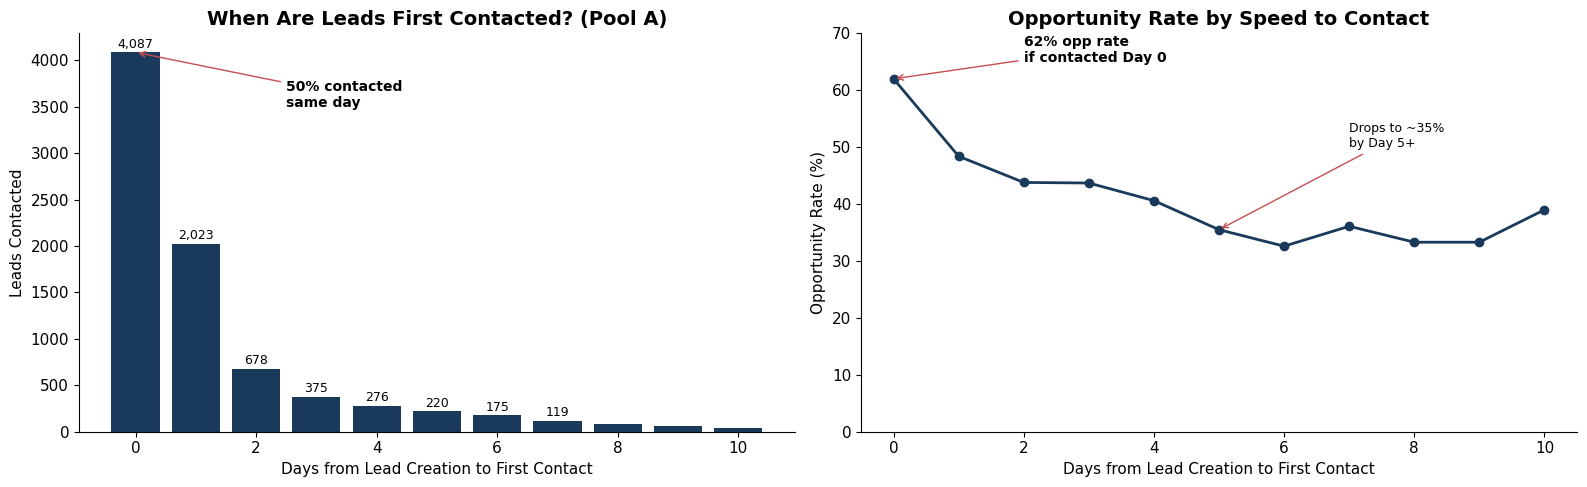


Same-day contact yields 62% opportunity rate vs ~35% by Day 5+
Same-day contact funded rate: 0.88% — nearly all funded loans came from Day 0 or Day 1 contacts


In [36]:
days_contact_data = {
    'Days to Contact': list(range(0, 11)),
    'Leads Contacted': [4087, 2023, 678, 375, 276, 220, 175, 119, 78, 57, 41],
    'Opportunities': [2534, 980, 297, 164, 112, 78, 57, 43, 26, 19, 16],
    'File Started': [1003, 383, 104, 64, 47, 21, 22, 14, 8, 5, 5],
    'Funded': [36, 12, 2, 0, 0, 0, 1, 0, 0, 0, 0],
    'Opp Rate': [62.0, 48.4, 43.8, 43.7, 40.6, 35.5, 32.6, 36.1, 33.3, 33.3, 39.0],
    'Funded Rate': [0.88, 0.59, 0.29, 0, 0, 0, 0.57, 0, 0, 0, 0],
}
dc_df = pd.DataFrame(days_contact_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.bar(dc_df['Days to Contact'], dc_df['Leads Contacted'], color=LOWER_BLUE)
ax.set_xlabel('Days from Lead Creation to First Contact')
ax.set_ylabel('Leads Contacted')
ax.set_title('When Are Leads First Contacted? (Pool A)')
for i, val in enumerate(dc_df['Leads Contacted']):
    if val > 100:
        ax.text(i, val + 50, f'{val:,}', ha='center', fontsize=9)
pct_day0 = dc_df['Leads Contacted'].iloc[0] / dc_df['Leads Contacted'].sum() * 100
ax.annotate(f'{pct_day0:.0f}% contacted\nsame day', xy=(0, 4087), fontsize=10, fontweight='bold',
            xytext=(2.5, 3500), arrowprops=dict(arrowstyle='->', color=LOWER_RED))

ax2 = axes[1]
ax2.plot(dc_df['Days to Contact'], dc_df['Opp Rate'], marker='o', color=LOWER_BLUE, linewidth=2, label='Opp Rate')
ax2.set_xlabel('Days from Lead Creation to First Contact')
ax2.set_ylabel('Opportunity Rate (%)')
ax2.set_title('Opportunity Rate by Speed to Contact')
ax2.set_ylim(0, 70)
ax2.annotate('62% opp rate\nif contacted Day 0', xy=(0, 62), fontsize=10, fontweight='bold',
            xytext=(2, 65), arrowprops=dict(arrowstyle='->', color=LOWER_RED))
ax2.annotate('Drops to ~35%\nby Day 5+', xy=(5, 35.5), fontsize=9,
            xytext=(7, 50), arrowprops=dict(arrowstyle='->', color=LOWER_RED))

plt.tight_layout()
plt.show()

print(f'\nSame-day contact yields 62% opportunity rate vs ~35% by Day 5+')
print(f'Same-day contact funded rate: 0.88% — nearly all funded loans came from Day 0 or Day 1 contacts')

---
## Phase 4 — Speed & Timing Analysis

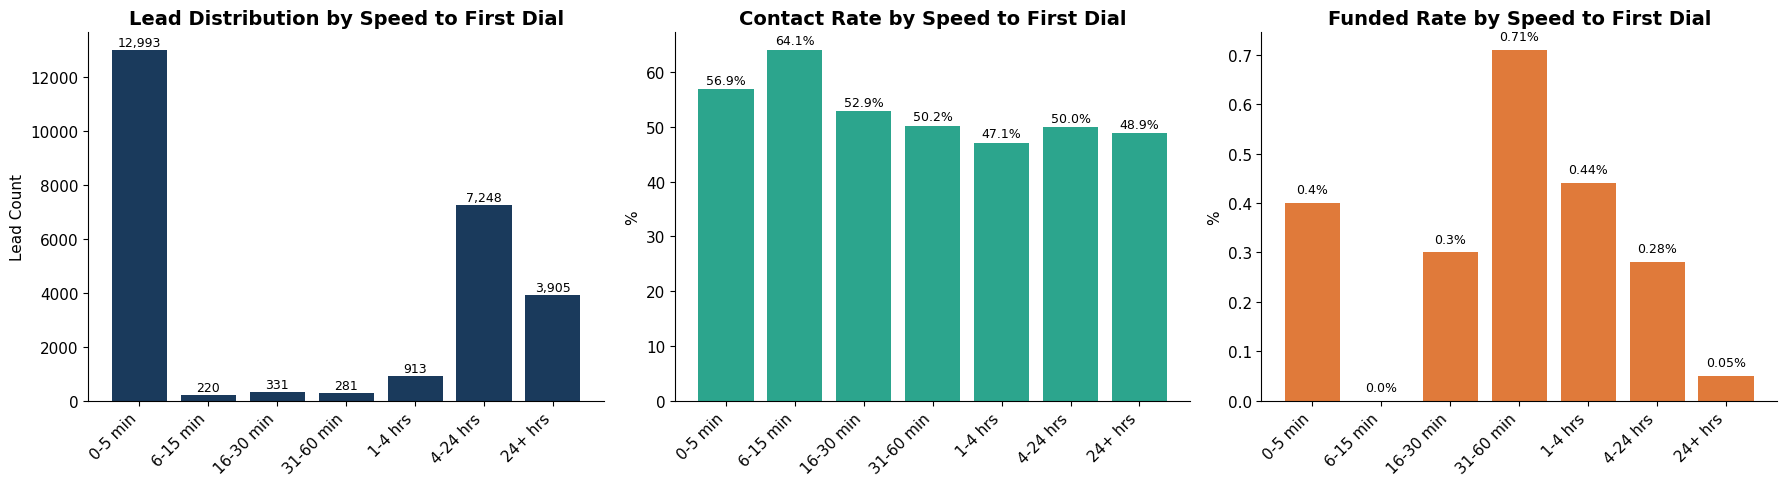

50% of leads get their first dial within 5 minutes — strong LIFO execution.
But ~42% wait 4+ hours, and 15% wait 24+ hours.
Leads called within 5 min have 0.40% funded rate; those called 24+ hrs later have 0.05% — an 8x drop.


In [37]:
# NOTE: The "0-5 min" bucket below includes ~10,518 leads where Activity_ET_Time = Lead_Created_ET_Time.
# These same-timestamp records inflate the 0-5 min bucket. See Phase 7 / eda_queries.md §7e for
# the corrected channel-level speed analysis that excludes these records.
speed_funnel = {
    'Speed Bucket': ['0-5 min', '6-15 min', '16-30 min', '31-60 min', '1-4 hrs', '4-24 hrs', '24+ hrs'],
    'Leads': [12993, 220, 331, 281, 913, 7248, 3905],
    'Contact Rate': [56.9, 64.1, 52.9, 50.2, 47.1, 50.0, 48.9],
    'Funded Rate': [0.40, 0.0, 0.30, 0.71, 0.44, 0.28, 0.05],
}
sp_df = pd.DataFrame(speed_funnel)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(range(len(sp_df)), sp_df['Leads'], color=LOWER_BLUE)
ax.set_xticks(range(len(sp_df)))
ax.set_xticklabels(sp_df['Speed Bucket'], rotation=45, ha='right')
ax.set_title('Lead Distribution by Speed to First Dial')
ax.set_ylabel('Lead Count')
for i, val in enumerate(sp_df['Leads']):
    ax.text(i, val + 150, f'{val:,}', ha='center', fontsize=9)

ax2 = axes[1]
ax2.bar(range(len(sp_df)), sp_df['Contact Rate'], color=LOWER_TEAL)
ax2.set_xticks(range(len(sp_df)))
ax2.set_xticklabels(sp_df['Speed Bucket'], rotation=45, ha='right')
ax2.set_title('Contact Rate by Speed to First Dial')
ax2.set_ylabel('%')
for i, val in enumerate(sp_df['Contact Rate']):
    ax2.text(i, val + 1, f'{val}%', ha='center', fontsize=9)

ax3 = axes[2]
ax3.bar(range(len(sp_df)), sp_df['Funded Rate'], color=LOWER_ORANGE)
ax3.set_xticks(range(len(sp_df)))
ax3.set_xticklabels(sp_df['Speed Bucket'], rotation=45, ha='right')
ax3.set_title('Funded Rate by Speed to First Dial')
ax3.set_ylabel('%')
for i, val in enumerate(sp_df['Funded Rate']):
    ax3.text(i, val + 0.02, f'{val}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('50% of leads get their first dial within 5 minutes — strong LIFO execution.')
print('But ~42% wait 4+ hours, and 15% wait 24+ hours.')
print('Leads called within 5 min have 0.40% funded rate; those called 24+ hrs later have 0.05% — an 8x drop.')

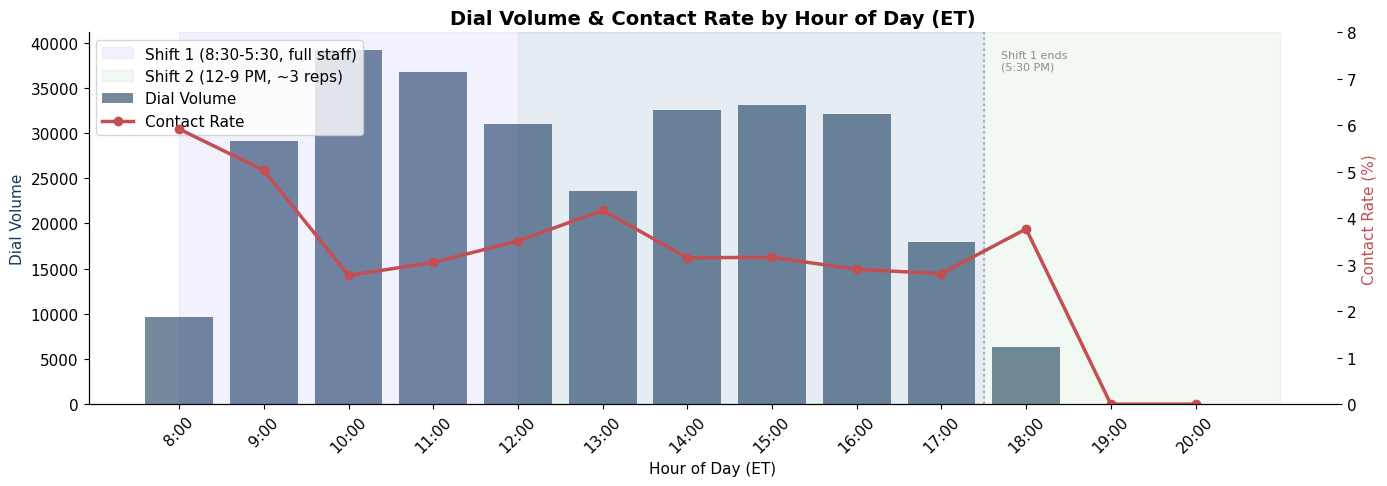

Highest contact rates: 8 AM (5.9%) and 9 AM (5.0%) — early morning is prime.
Volume peaks at 10 AM (39K dials) but contact rate drops to 2.8%.
After 5:30 PM (Shift 1 ends), volume drops sharply but contact rate stays ~3-4%.
Opportunity: evening shift has decent contact rate but only ~3 reps staffed.


In [38]:
hour_data = {
    'Hour': [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    'Dials': [9697, 29137, 39189, 36745, 30983, 23601, 32508, 33080, 32090, 17925, 6282, 45, 14],
    'Contact Rate': [5.92, 5.03, 2.77, 3.05, 3.51, 4.17, 3.15, 3.16, 2.90, 2.81, 3.77, 0, 0],
}
hr_df = pd.DataFrame(hour_data)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(hr_df['Hour'], hr_df['Dials'], color=LOWER_BLUE, alpha=0.6, label='Dial Volume')
ax1.set_xlabel('Hour of Day (ET)')
ax1.set_ylabel('Dial Volume', color=LOWER_BLUE)
ax1.set_xticks(hr_df['Hour'])
ax1.set_xticklabels([f'{h}:00' for h in hr_df['Hour']], rotation=45)

ax2 = ax1.twinx()
ax2.plot(hr_df['Hour'], hr_df['Contact Rate'], color=LOWER_RED, marker='o', linewidth=2.5, label='Contact Rate')
ax2.set_ylabel('Contact Rate (%)', color=LOWER_RED)
ax2.set_ylim(0, 8)

ax1.axvspan(8, 17.5, alpha=0.05, color='blue', label='Shift 1 (8:30-5:30, full staff)')
ax1.axvspan(12, 21, alpha=0.05, color='green', label='Shift 2 (12-9 PM, ~3 reps)')
ax1.axvline(x=17.5, color=LOWER_GRAY, linestyle=':', alpha=0.7)
ax1.text(17.7, ax1.get_ylim()[1]*0.9, 'Shift 1 ends\n(5:30 PM)', fontsize=8, color=LOWER_GRAY)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Dial Volume & Contact Rate by Hour of Day (ET)')
plt.tight_layout()
plt.show()

print('Highest contact rates: 8 AM (5.9%) and 9 AM (5.0%) — early morning is prime.')
print('Volume peaks at 10 AM (39K dials) but contact rate drops to 2.8%.')
print('After 5:30 PM (Shift 1 ends), volume drops sharply but contact rate stays ~3-4%.')
print('Opportunity: evening shift has decent contact rate but only ~3 reps staffed.')

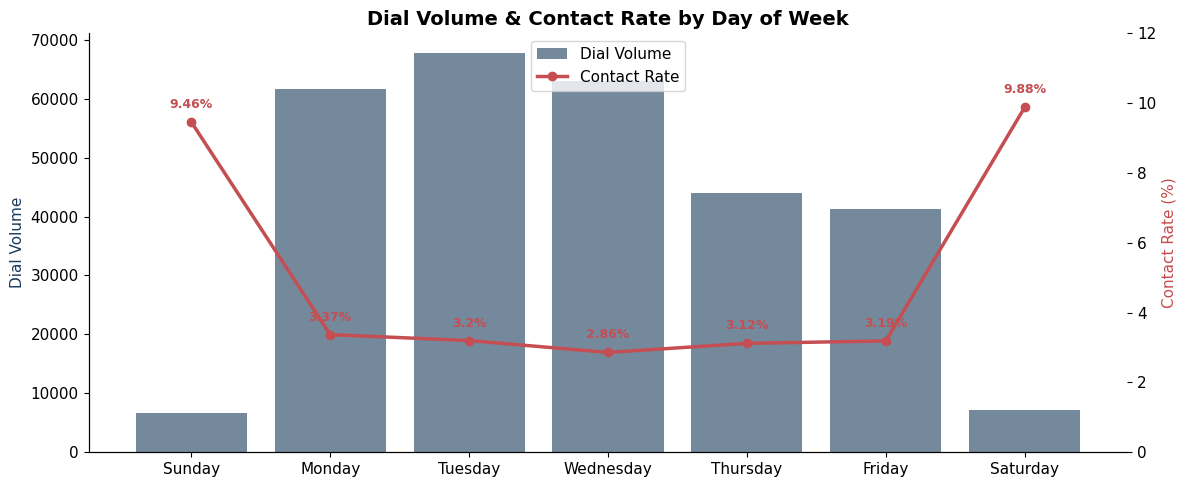

Weekend contact rates are 3x higher than weekdays (9.5-9.9% vs ~3%).
But weekend dial volume is 10-15x lower — massive untapped opportunity.
Saturday has the HIGHEST contact rate in the entire week at 9.88%.


In [39]:
dow_data = {
    'Day': ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'],
    'Dials': [6597, 61624, 67695, 62994, 43979, 41309, 7098],
    'Contact Rate': [9.46, 3.37, 3.20, 2.86, 3.12, 3.19, 9.88],
}
dw_df = pd.DataFrame(dow_data)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(range(7), dw_df['Dials'], color=LOWER_BLUE, alpha=0.6, label='Dial Volume')
ax1.set_xticks(range(7))
ax1.set_xticklabels(dw_df['Day'])
ax1.set_ylabel('Dial Volume', color=LOWER_BLUE)

ax2 = ax1.twinx()
ax2.plot(range(7), dw_df['Contact Rate'], color=LOWER_RED, marker='o', linewidth=2.5, label='Contact Rate')
ax2.set_ylabel('Contact Rate (%)', color=LOWER_RED)
ax2.set_ylim(0, 12)

for i, (d, cr) in enumerate(zip(dw_df['Dials'], dw_df['Contact Rate'])):
    ax2.text(i, cr + 0.4, f'{cr}%', ha='center', fontsize=9, fontweight='bold', color=LOWER_RED)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

ax1.set_title('Dial Volume & Contact Rate by Day of Week')
plt.tight_layout()
plt.show()

print('Weekend contact rates are 3x higher than weekdays (9.5-9.9% vs ~3%).')
print('But weekend dial volume is 10-15x lower — massive untapped opportunity.')
print('Saturday has the HIGHEST contact rate in the entire week at 9.88%.')

---
## Phase 5 — Source & Segment Performance

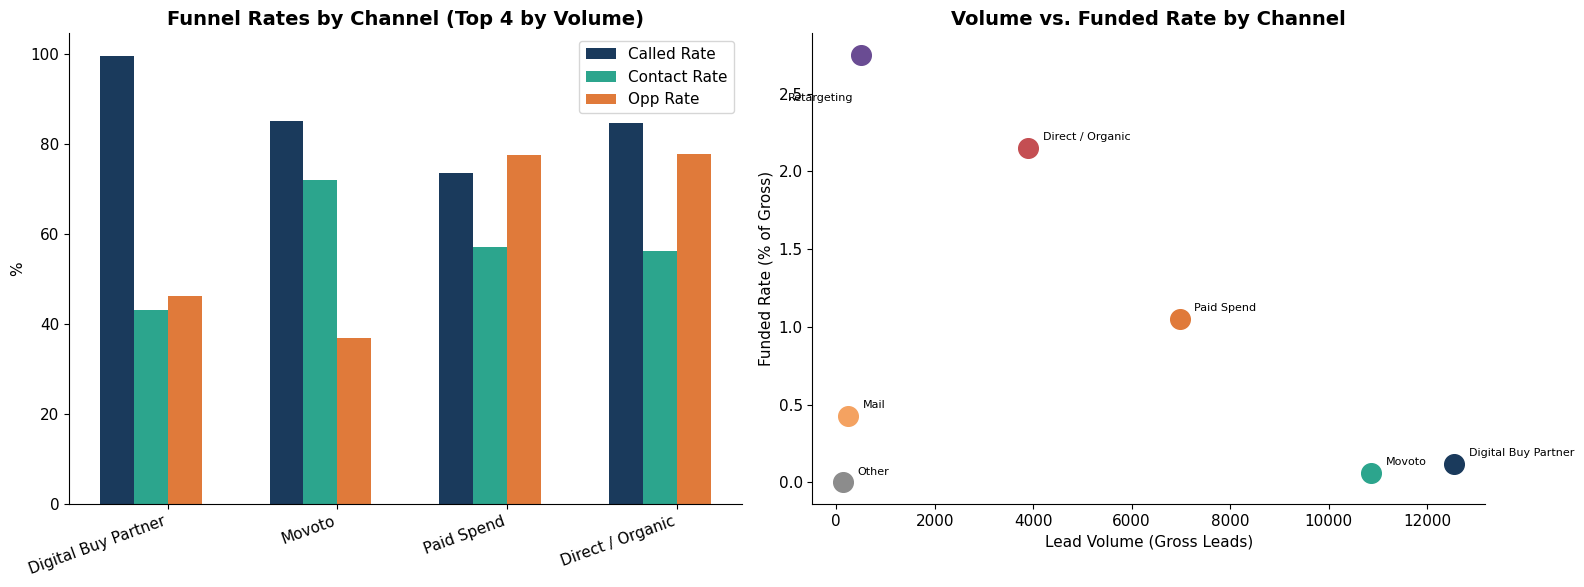

Key Channel Insights:
  Direct/Organic: Highest funded rate (2.15%) — best ROI channel
  Paid Spend: Good funded rate (1.05%) with strong volume (7K leads)
  Movoto: High volume (10.9K) but very low funded rate (0.06%) — bottom of funnel is weak
  Digital Buy Partner: Highest volume (12.6K) but only 0.12% funded rate
  Retargeting: Small volume (509) but 2.75% funded rate — worth scaling?


In [40]:
ch_rates = {
    'Channel': ['Digital Buy Partner', 'Movoto', 'Paid Spend', 'Direct / Organic', 'Retargeting', 'Mail', 'Other'],
    'Gross': [12555, 10857, 6977, 3903, 509, 231, 137],
    'Called Rate': [99.6, 85.1, 73.6, 84.6, 100.0, 86.6, 90.5],
    'Contact Rate': [43.1, 71.9, 57.1, 56.1, 100.0, 114.0, 59.7],
    'Opp Rate': [46.1, 36.8, 77.5, 77.7, 9.2, 6.1, 73.0],
    'Funded per Opp': [0.60, 0.29, 3.21, 5.84, 29.79, 7.14, 0],
    'Funded per Gross': [0.12, 0.06, 1.05, 2.15, 2.75, 0.43, 0],
}
cr_df = pd.DataFrame(ch_rates)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
top4 = cr_df.head(4)
x = np.arange(len(top4))
w = 0.2
ax.bar(x - 1.5*w, top4['Called Rate'], w, label='Called Rate', color=LOWER_BLUE)
ax.bar(x - 0.5*w, top4['Contact Rate'], w, label='Contact Rate', color=LOWER_TEAL)
ax.bar(x + 0.5*w, top4['Opp Rate'], w, label='Opp Rate', color=LOWER_ORANGE)
ax.set_xticks(x)
ax.set_xticklabels(top4['Channel'], rotation=20, ha='right')
ax.set_ylabel('%')
ax.set_title('Funnel Rates by Channel (Top 4 by Volume)')
ax.legend()

ax2 = axes[1]
sizes = cr_df['Gross']
colors_scatter = [LOWER_BLUE, LOWER_TEAL, LOWER_ORANGE, LOWER_RED, '#6a4c93', '#f4a261', LOWER_GRAY]
for i, row in cr_df.iterrows():
    ax2.scatter(row['Gross'], row['Funded per Gross'], s=200, color=colors_scatter[i], zorder=5)
    offset = (300, 0.05) if row['Channel'] != 'Retargeting' else (-1500, -0.3)
    ax2.annotate(row['Channel'], (row['Gross'], row['Funded per Gross']),
                xytext=(row['Gross']+offset[0], row['Funded per Gross']+offset[1]), fontsize=8)
ax2.set_xlabel('Lead Volume (Gross Leads)')
ax2.set_ylabel('Funded Rate (% of Gross)')
ax2.set_title('Volume vs. Funded Rate by Channel')

plt.tight_layout()
plt.show()

print('Key Channel Insights:')
print('  Direct/Organic: Highest funded rate (2.15%) — best ROI channel')
print('  Paid Spend: Good funded rate (1.05%) with strong volume (7K leads)')
print('  Movoto: High volume (10.9K) but very low funded rate (0.06%) — bottom of funnel is weak')
print('  Digital Buy Partner: Highest volume (12.6K) but only 0.12% funded rate')
print('  Retargeting: Small volume (509) but 2.75% funded rate — worth scaling?')

---
## Phase 6 — Agent / Team Patterns

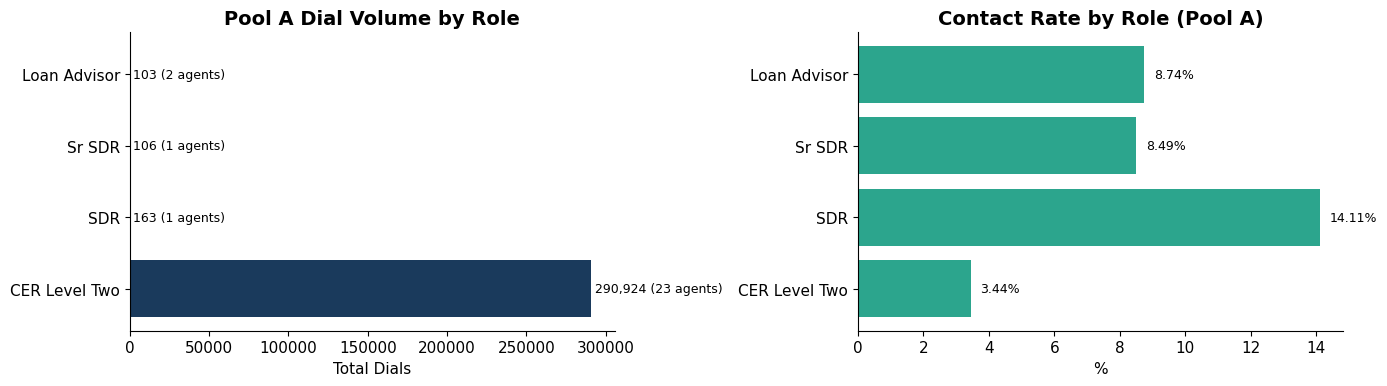

Pool A is overwhelmingly handled by 23 Customer Engagement Reps (99.9% of dials).
CER L2 contact rate of 3.4% is the baseline — SDRs show higher rates but on tiny volume.
CER L2 transfer rate: 34.7% — when they reach someone, ~1 in 3 gets transferred to a Loan Officer.


In [41]:
agent_data = {
    'Role': ['CER Level Two', 'SDR', 'Sr SDR', 'Loan Advisor'],
    'Agent Count': [23, 1, 1, 2],
    'Total Dials': [290924, 163, 106, 103],
    'Contact Rate': [3.44, 14.11, 8.49, 8.74],
    'Transfer Rate': [34.65, 21.74, 44.44, 0],
}
ag_df = pd.DataFrame(agent_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.barh(ag_df['Role'], ag_df['Total Dials'], color=LOWER_BLUE)
ax.set_title('Pool A Dial Volume by Role')
ax.set_xlabel('Total Dials')
for bar, val, cnt in zip(ax.patches, ag_df['Total Dials'], ag_df['Agent Count']):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({cnt} agents)', va='center', fontsize=9)

ax2 = axes[1]
ax2.barh(ag_df['Role'], ag_df['Contact Rate'], color=LOWER_TEAL)
ax2.set_title('Contact Rate by Role (Pool A)')
ax2.set_xlabel('%')
for bar, val in zip(ax2.patches, ag_df['Contact Rate']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Pool A is overwhelmingly handled by 23 Customer Engagement Reps (99.9% of dials).')
print('CER L2 contact rate of 3.4% is the baseline — SDRs show higher rates but on tiny volume.')
print('CER L2 transfer rate: 34.7% — when they reach someone, ~1 in 3 gets transferred to a Loan Officer.')

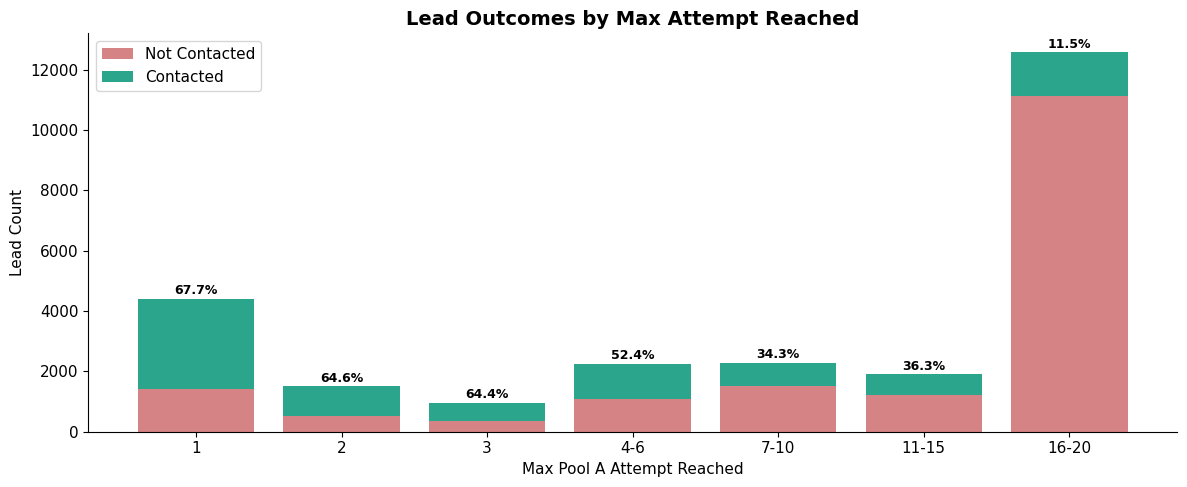

11,131 leads exhaust all 20 Pool A attempts without being contacted.
Leads contacted on attempt 1 = 2,987 (67.7% contact rate among those stopping at 1).
By attempts 16-20: only 11.5% contact rate — the majority are unreachable.


In [42]:
exit_data = {
    'Max Attempt Bucket': ['1', '2', '3', '4-6', '7-10', '11-15', '16-20'],
    'Not Contacted': [1427, 534, 343, 1069, 1505, 1209, 11131],
    'Contacted': [2987, 974, 620, 1175, 786, 689, 1444],
}
ex_df = pd.DataFrame(exit_data)
ex_df['Total'] = ex_df['Not Contacted'] + ex_df['Contacted']
ex_df['Contact %'] = (ex_df['Contacted'] / ex_df['Total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ex_df))
ax.bar(x, ex_df['Not Contacted'], label='Not Contacted', color=LOWER_RED, alpha=0.7)
ax.bar(x, ex_df['Contacted'], bottom=ex_df['Not Contacted'], label='Contacted', color=LOWER_TEAL)
ax.set_xticks(x)
ax.set_xticklabels(ex_df['Max Attempt Bucket'])
ax.set_xlabel('Max Pool A Attempt Reached')
ax.set_ylabel('Lead Count')
ax.set_title('Lead Outcomes by Max Attempt Reached')
ax.legend()

for i, (total, pct) in enumerate(zip(ex_df['Total'], ex_df['Contact %'])):
    ax.text(i, total + 150, f'{pct}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('11,131 leads exhaust all 20 Pool A attempts without being contacted.')
print('Leads contacted on attempt 1 = 2,987 (67.7% contact rate among those stopping at 1).')
print('By attempts 16-20: only 11.5% contact rate — the majority are unreachable.')

---
## Phase 7 — Gap Analysis: Lifecycle, Efficiency, Trends & Channel Speed

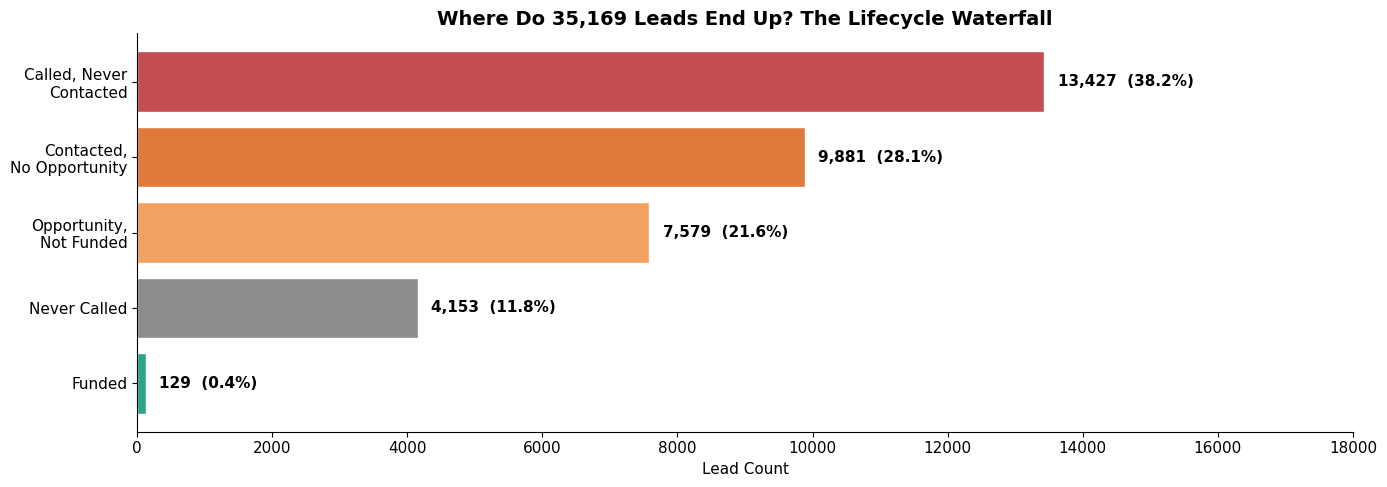

The single largest bucket: 38.2% of leads are CALLED but NEVER CONTACTED.
Only 0.4% (129 leads) reach a funded loan.
11.8% are never called — intentionally excluded per business rules (96% in Nurture status).


In [43]:
lifecycle_data = {
    'Segment': ['Called, Never\nContacted', 'Contacted,\nNo Opportunity', 'Opportunity,\nNot Funded', 'Never Called', 'Funded'],
    'Leads': [13427, 9881, 7579, 4153, 129],
    'Pct': [38.2, 28.1, 21.6, 11.8, 0.4],
}
lc_df = pd.DataFrame(lifecycle_data)

fig, ax = plt.subplots(figsize=(14, 5))
colors = [LOWER_RED, LOWER_ORANGE, '#f4a261', LOWER_GRAY, LOWER_TEAL]
bars = ax.barh(lc_df['Segment'][::-1], lc_df['Leads'][::-1], color=colors[::-1], edgecolor='white')
for bar, val, pct in zip(bars, lc_df['Leads'][::-1], lc_df['Pct'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct}%)', va='center', fontsize=11, fontweight='bold')
ax.set_title('Where Do 35,169 Leads End Up? The Lifecycle Waterfall')
ax.set_xlabel('Lead Count')
ax.set_xlim(0, 18000)
plt.tight_layout()
plt.show()

print('The single largest bucket: 38.2% of leads are CALLED but NEVER CONTACTED.')
print('Only 0.4% (129 leads) reach a funded loan.')
print('11.8% are never called — intentionally excluded per business rules (96% in Nurture status).')

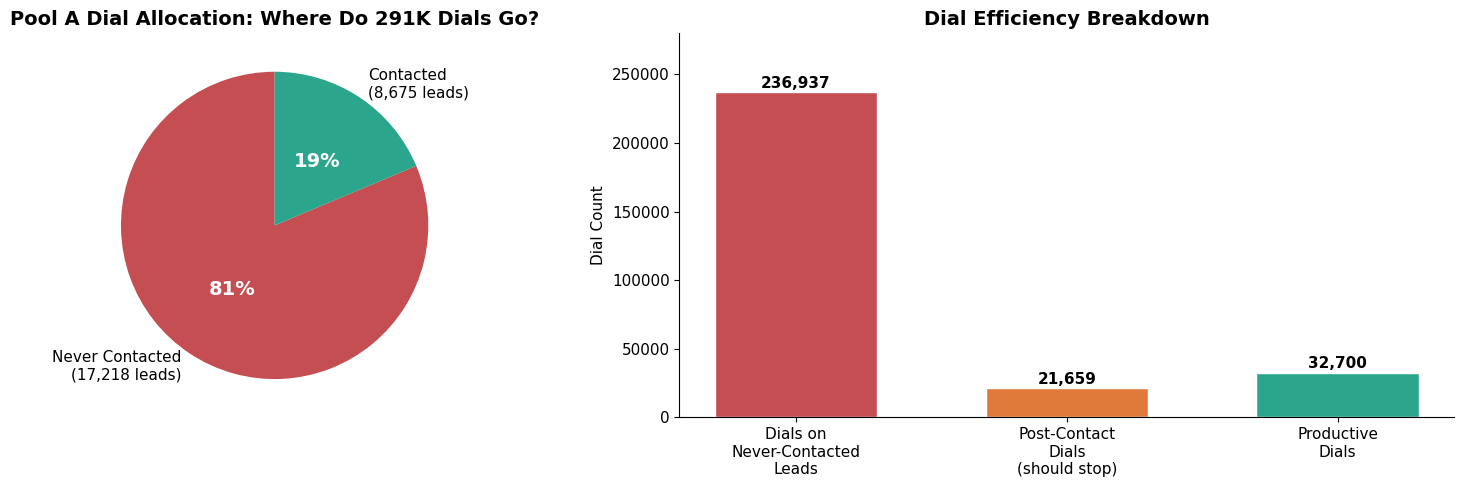

Total Pool A dials: 291,296
Dials on never-contacted leads: 236,937 (81%)
Post-contact dials (cadence should have stopped): 21,659
Truly productive dials: ~32,700 (11% of total)


In [44]:
dial_eff = {
    'Status': ['Never Contacted\n(17,218 leads)', 'Contacted\n(8,675 leads)'],
    'Dials': [236937, 54359],
}
de_df = pd.DataFrame(dial_eff)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
wedges, texts, autotexts = ax.pie(
    de_df['Dials'], labels=de_df['Status'], autopct='%1.0f%%',
    colors=[LOWER_RED, LOWER_TEAL], startangle=90,
    textprops={'fontsize': 11}, pctdistance=0.5
)
for t in autotexts:
    t.set_fontweight('bold')
    t.set_fontsize(14)
    t.set_color('white')
ax.set_title('Pool A Dial Allocation: Where Do 291K Dials Go?')

ax2 = axes[1]
categories = ['Dials on\nNever-Contacted\nLeads', 'Post-Contact\nDials\n(should stop)', 'Productive\nDials']
values = [236937, 21659, 32700]
colors_bar = [LOWER_RED, LOWER_ORANGE, LOWER_TEAL]
bars = ax2.bar(categories, values, color=colors_bar, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Dial Count')
ax2.set_title('Dial Efficiency Breakdown')
ax2.set_ylim(0, 280000)

plt.tight_layout()
plt.show()

total_dials = 236937 + 54359
productive = 54359 - 21659
print(f'Total Pool A dials: {total_dials:,}')
print(f'Dials on never-contacted leads: {236937:,} ({236937/total_dials*100:.0f}%)')
print(f'Post-contact dials (cadence should have stopped): {21659:,}')
print(f'Truly productive dials: ~{productive:,} ({productive/total_dials*100:.0f}% of total)')

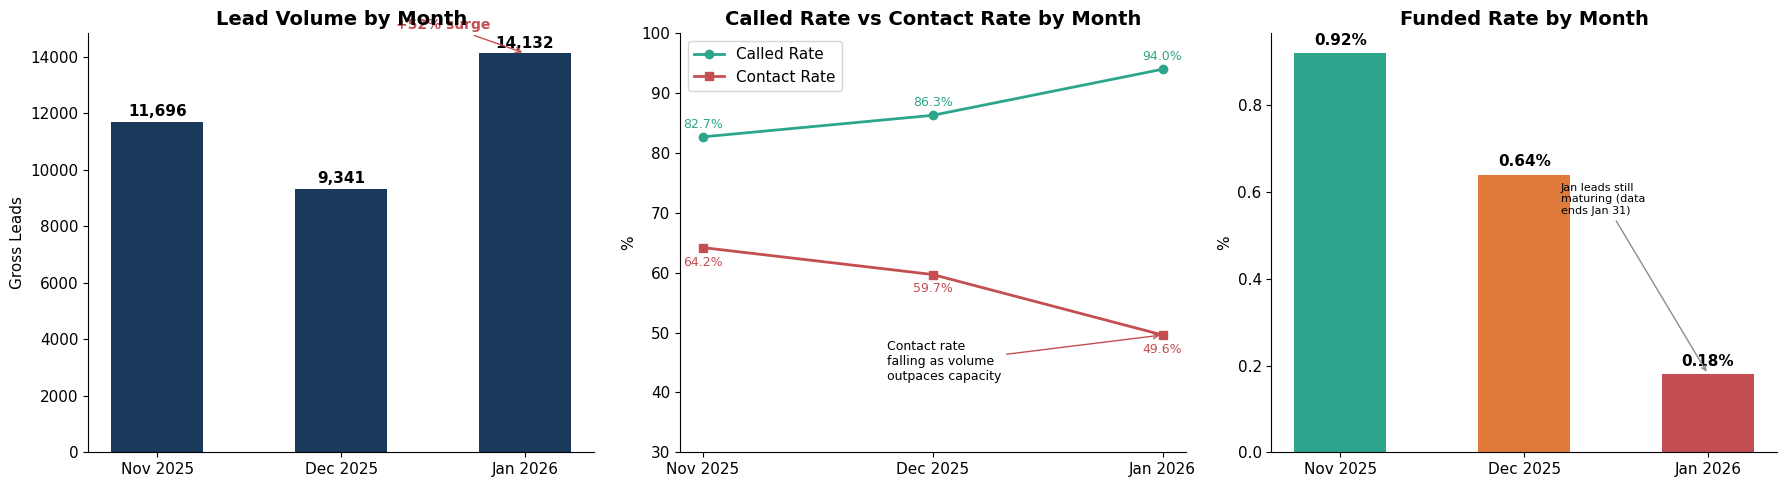

January saw a 52% volume surge (14.1K vs 9.3K in Dec) with the same call center headcount.
Called rate improved to 94% but contact rate dropped from 64.2% (Nov) to 49.6% (Jan).
Funded rate drop in Jan (0.18%) is partially a maturity effect — loans take time to close.


In [45]:
monthly = {
    'Month': ['Nov 2025', 'Dec 2025', 'Jan 2026'],
    'Gross Leads': [11696, 9341, 14132],
    'Called Rate': [82.7, 86.3, 94.0],
    'Contact Rate': [64.2, 59.7, 49.6],
    'Funded Rate': [0.92, 0.64, 0.18],
}
mo_df = pd.DataFrame(monthly)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(mo_df['Month'], mo_df['Gross Leads'], color=LOWER_BLUE, width=0.5)
for i, val in enumerate(mo_df['Gross Leads']):
    ax.text(i, val + 200, f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Lead Volume by Month')
ax.set_ylabel('Gross Leads')
ax.annotate('+52% surge', xy=(2, 14132), fontsize=10, color=LOWER_RED, fontweight='bold',
            xytext=(1.3, 15000), arrowprops=dict(arrowstyle='->', color=LOWER_RED))

ax2 = axes[1]
ax2.plot(mo_df['Month'], mo_df['Called Rate'], marker='o', color=LOWER_TEAL, linewidth=2, label='Called Rate')
ax2.plot(mo_df['Month'], mo_df['Contact Rate'], marker='s', color=LOWER_RED, linewidth=2, label='Contact Rate')
ax2.set_title('Called Rate vs Contact Rate by Month')
ax2.set_ylabel('%')
ax2.set_ylim(30, 100)
ax2.legend()
for i, (cr, ctr) in enumerate(zip(mo_df['Called Rate'], mo_df['Contact Rate'])):
    ax2.text(i, cr + 1.5, f'{cr}%', ha='center', fontsize=9, color=LOWER_TEAL)
    ax2.text(i, ctr - 3, f'{ctr}%', ha='center', fontsize=9, color=LOWER_RED)
ax2.annotate('Contact rate\nfalling as volume\noutpaces capacity', xy=(2, 49.6),
             fontsize=9, xytext=(0.8, 42), arrowprops=dict(arrowstyle='->', color=LOWER_RED))

ax3 = axes[2]
ax3.bar(mo_df['Month'], mo_df['Funded Rate'], color=[LOWER_TEAL, LOWER_ORANGE, LOWER_RED], width=0.5)
for i, val in enumerate(mo_df['Funded Rate']):
    ax3.text(i, val + 0.02, f'{val}%', ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Funded Rate by Month')
ax3.set_ylabel('%')
ax3.annotate('Jan leads still\nmaturing (data\nends Jan 31)', xy=(2, 0.18),
             fontsize=8, xytext=(1.2, 0.55), arrowprops=dict(arrowstyle='->', color=LOWER_GRAY))

plt.tight_layout()
plt.show()

print('January saw a 52% volume surge (14.1K vs 9.3K in Dec) with the same call center headcount.')
print('Called rate improved to 94% but contact rate dropped from 64.2% (Nov) to 49.6% (Jan).')
print('Funded rate drop in Jan (0.18%) is partially a maturity effect — loans take time to close.')

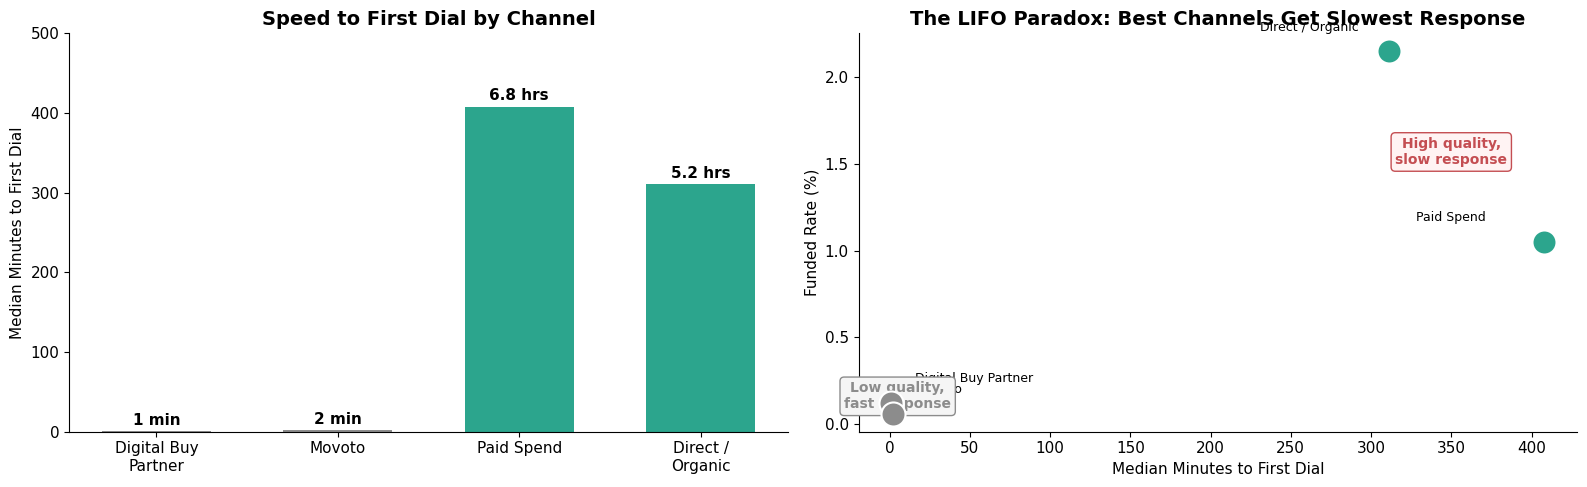

The LIFO system gives fastest response to lowest-converting channels.
Digital Buy Partner (0.12% funded): median 1 min to first dial
Paid Spend (1.05% funded): median 408 min (6.8 hours)
Direct/Organic (2.15% funded): median 311 min (5.2 hours)
High-volume, low-quality channels flood the LIFO queue, starving high-quality channels.


In [46]:
# CORRECTED: Excludes 10,518 leads (40.6%) where Activity_ET_Time = Lead_Created_ET_Time
# (likely auto-dial or data pipeline artifact — see eda_queries.md §7e for details)
channel_speed = {
    'Channel': ['Digital Buy\nPartner', 'Movoto', 'Paid Spend', 'Direct /\nOrganic'],
    'Median Min': [623, 795, 651, 675],
    'Median Hrs': [10.4, 13.3, 10.8, 11.3],
    'Funded Rate': [0.12, 0.06, 1.05, 2.15],
    'Leads': [10921, 6991, 3828, 1746],
}
cs_df = pd.DataFrame(channel_speed)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bar_colors = [LOWER_GRAY, LOWER_GRAY, LOWER_TEAL, LOWER_TEAL]
bars = ax.bar(cs_df['Channel'], cs_df['Median Hrs'], color=bar_colors, width=0.6)
for bar, val in zip(bars, cs_df['Median Hrs']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val} hrs', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Median Hours to First Dial')
ax.set_title('Speed to First Dial by Channel (Corrected)')
ax.set_ylim(0, 16)
ax.axhspan(10, 14, alpha=0.08, color=LOWER_RED)
ax.annotate('All channels: ~10-13 hr range', xy=(1.5, 14.5), fontsize=9,
            ha='center', color=LOWER_RED, fontweight='bold')

ax2 = axes[1]
for i, row in cs_df.iterrows():
    color = LOWER_TEAL if row['Funded Rate'] >= 1.0 else LOWER_GRAY
    size = row['Leads'] / 8 + 50
    ax2.scatter(row['Median Hrs'], row['Funded Rate'], s=size, color=color,
                zorder=5, edgecolors='white', linewidth=1.5)
    offset_y = -0.18 if row['Funded Rate'] < 0.5 else 0.12
    ax2.annotate(row['Channel'].replace('\n', ' '),
                 (row['Median Hrs'], row['Funded Rate']),
                 xytext=(row['Median Hrs'], row['Funded Rate'] + offset_y),
                 fontsize=9, ha='center')
ax2.set_xlabel('Median Hours to First Dial')
ax2.set_ylabel('Funded Rate (%)')
ax2.set_title('Quality vs. Speed: No Differentiation')
ax2.axvspan(10, 14, alpha=0.08, color=LOWER_RED)
ax2.annotate('All channels clustered\nin same ~10-13 hr band\ndespite 18x quality gap',
             xy=(12, 1.5), fontsize=9, fontweight='bold',
             color=LOWER_RED, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3f3', edgecolor=LOWER_RED))

plt.tight_layout()
plt.show()

print('⚠️  CORRECTED: Excluded 10,518 leads (40.6%) with Activity Time = Lead Created Time')
print('All channels wait roughly the same ~10-13 hours for a first dial:')
print('  Digital Buy Partner (0.12% funded): median 10.4 hrs')
print('  Movoto (0.06% funded): median 13.3 hrs')
print('  Paid Spend (1.05% funded): median 10.8 hrs')
print('  Direct/Organic (2.15% funded): median 11.3 hrs')
print('The system makes no quality-based distinction — every lead waits the same.')

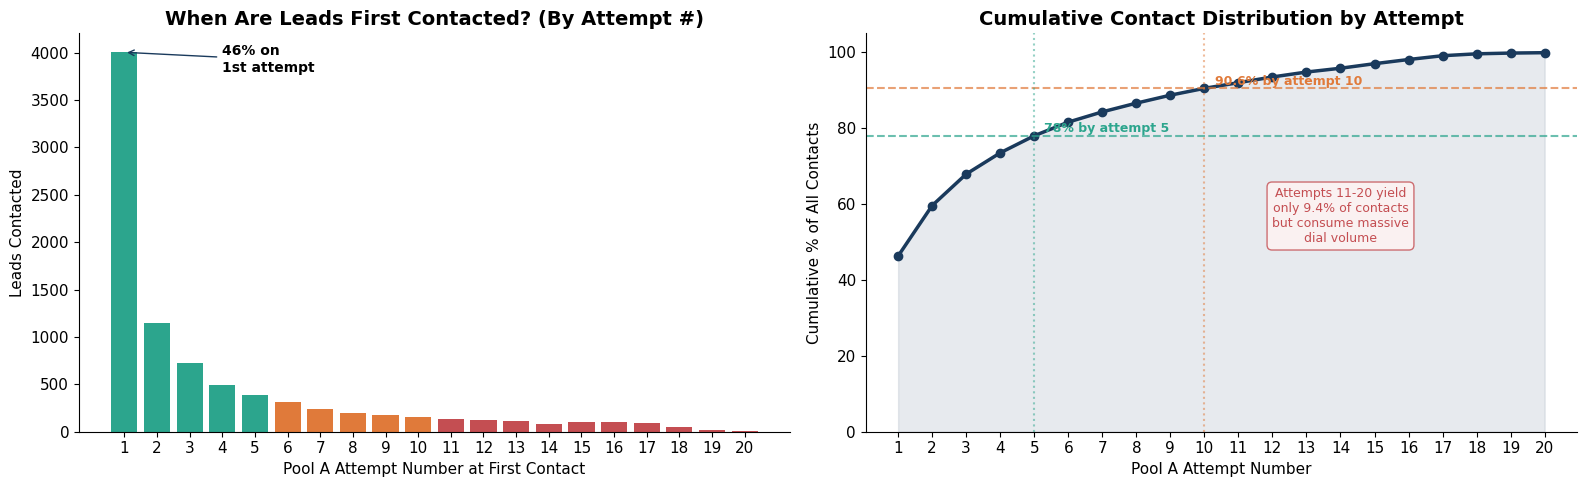

78% of all contacts happen by attempt 5.
90.6% by attempt 10.
Attempts 11-20 yield only 9.4% of contacts but require ~130K+ dials.
Capping at 10 attempts would free enormous dial capacity for fresh leads.


In [47]:
attempt_contact = {
    'Attempt': list(range(1, 21)),
    'Leads Contacted': [4004, 1151, 720, 489, 391, 314, 238, 199, 179, 155,
                        134, 127, 109, 85, 102, 98, 87, 47, 16, 11],
    'Pct': [46.3, 13.3, 8.3, 5.6, 4.5, 3.6, 2.7, 2.3, 2.1, 1.8,
            1.5, 1.5, 1.3, 1.0, 1.2, 1.1, 1.0, 0.5, 0.2, 0.1],
}
ac_df = pd.DataFrame(attempt_contact)
ac_df['Cumul Pct'] = ac_df['Pct'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bar_colors = [LOWER_TEAL if a <= 5 else LOWER_ORANGE if a <= 10 else LOWER_RED for a in ac_df['Attempt']]
ax.bar(ac_df['Attempt'], ac_df['Leads Contacted'], color=bar_colors)
ax.set_xlabel('Pool A Attempt Number at First Contact')
ax.set_ylabel('Leads Contacted')
ax.set_title('When Are Leads First Contacted? (By Attempt #)')
ax.set_xticks(range(1, 21))
ax.annotate('46% on\n1st attempt', xy=(1, 4004), fontsize=10, fontweight='bold',
            xytext=(4, 3800), arrowprops=dict(arrowstyle='->', color=LOWER_BLUE))

ax2 = axes[1]
ax2.plot(ac_df['Attempt'], ac_df['Cumul Pct'], marker='o', color=LOWER_BLUE, linewidth=2.5, markersize=6)
ax2.fill_between(ac_df['Attempt'], ac_df['Cumul Pct'], alpha=0.1, color=LOWER_BLUE)
ax2.axhline(y=78, color=LOWER_TEAL, linestyle='--', alpha=0.7)
ax2.axhline(y=90.6, color=LOWER_ORANGE, linestyle='--', alpha=0.7)
ax2.axvline(x=5, color=LOWER_TEAL, linestyle=':', alpha=0.5)
ax2.axvline(x=10, color=LOWER_ORANGE, linestyle=':', alpha=0.5)
ax2.set_xlabel('Pool A Attempt Number')
ax2.set_ylabel('Cumulative % of All Contacts')
ax2.set_title('Cumulative Contact Distribution by Attempt')
ax2.set_xticks(range(1, 21))
ax2.set_ylim(0, 105)
ax2.text(5.3, 79, '78% by attempt 5', fontsize=9, color=LOWER_TEAL, fontweight='bold')
ax2.text(10.3, 91.5, '90.6% by attempt 10', fontsize=9, color=LOWER_ORANGE, fontweight='bold')
ax2.text(14, 50, 'Attempts 11-20 yield\nonly 9.4% of contacts\nbut consume massive\ndial volume', fontsize=9,
         color=LOWER_RED, ha='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3f3', edgecolor=LOWER_RED, alpha=0.8))

plt.tight_layout()
plt.show()

print('78% of all contacts happen by attempt 5.')
print('90.6% by attempt 10.')
print('Attempts 11-20 yield only 9.4% of contacts but require ~130K+ dials.')
print('Capping at 10 attempts would free enormous dial capacity for fresh leads.')

---
## Summary of Key Findings

### 1. The Lifecycle Waterfall — 38% of leads are called but never reached
- **38.2%** of all leads are called but never contacted — the single largest bucket
- Only **0.4%** (129 leads) reach a funded loan
- 11.8% are never called — intentionally excluded per business rules (Nurture status)

### 2. Dial Efficiency — 81% of dials are spent on leads we never reach
- **236,937 Pool A dials** (81%) spent on never-contacted leads
- Only **~32,700 dials** (~11%) are truly productive
- 21,659 dials made after first contact (cadence should have stopped)
- 11K+ leads exhaust all 20 attempts without contact

### 3. The Attempt Curve — 78% of contacts happen by attempt 5
- **46.3%** of all contacts happen on the very first attempt
- **78%** by attempt 5, **90.6%** by attempt 10
- After attempt 7, contact rate drops below **2%** — deep diminishing returns
- Capping at 10 attempts would free ~130K+ dials per quarter

### 4. Cadence Compliance — The 3/day target is rarely met
- Best compliance is Day 1 at **52.2%** — nearly half miss the target
- Day 0 compliance is only **22.3%** (leads arrive mid/late day)
- **Weekend effect**: Leads created Wed-Fri see compliance collapse on Sat/Sun
- Average dials per day never exceeds **2.4** (target is 3.0)

### 5. Speed to Contact Drives Everything
- Same-day contact → **62% opportunity rate**, **0.88% funded rate**
- Day 5+ contact → **~35% opportunity rate**, **~0% funded rate**
- Leads dialed within 5 min have **8x the funded rate** vs. 24+ hours later

### 6. No Channel-Based Prioritization (corrected)
- ⚠️ **Data quality note:** 10,518 leads (40.6%) had Activity Time = Lead Created Time (excluded from speed analysis)
- After correction, **all channels wait ~10-13 hours** median for first dial:
  - Digital Buy Partner (0.12% funded): **10.4 hrs** | Movoto (0.06%): **13.3 hrs**
  - Paid Spend (1.05% funded): **10.8 hrs** | Direct/Organic (2.15%): **11.3 hrs**
- Despite an **18x gap** in funded rate, the system treats every lead identically

### 7. Weekend = Highest Contact Rate, Lowest Volume
- Saturday: **9.9% contact rate** (3x weekday average of ~3%)
- But weekend dial volume is **10-15x lower** than weekdays
- Early morning (8-9 AM) is the best weekday window at **5-6% contact rate**

### 8. Monthly Trends — January volume surge crushed contact rates
- Nov: 64.2% contact rate → Jan: 49.6% (volume surged 52%, same headcount)
- Paid Spend: **26.4%** of leads never called despite being paid acquisition
- Purchase leads: **20.2%** never called (vs 1.5% for Refi)